In [2]:
# 1. Autoreload magic
%load_ext autoreload
%autoreload 2

import sys
import warnings
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm  # The beautiful progress bar
import time                     # Just to artificially slow it down for 1 second so we can see the bar!

# Mute all Python warnings for a pristine notebook output
warnings.filterwarnings('ignore')

# 2. Point Jupyter to our source folder
sys.path.append('../src')

# 3. Import our custom pipeline tools
from marketing_pipeline import load_and_split_data, build_preprocessor, build_optimized_lgbm

# --- EXECUTION ---

X, y = load_and_split_data('../data/raw/online_shoppers_intention.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = build_preprocessor()
optimized_lgbm = build_optimized_lgbm(preprocessor)

# --- THE PROGRESS BAR ---

print("Initializing Marketing Conversion Pipeline...")

# We wrap our training step in a tqdm loop. 
# (We are looping 1 time, but we add a tiny sleep just so we can admire the UI)
for step in tqdm(range(1), desc="Training LightGBM Engine", bar_format='{l_bar}{bar:30}{r_bar}'):
    optimized_lgbm.fit(X_train, y_train)
    time.sleep(0.5) # A brief pause so we can actually see the green bar fill up

print("✅ Training complete. Engine is locked and loaded.")

Initializing Marketing Conversion Pipeline...


Training LightGBM Engine:   0%|                              | 0/1 [00:00<?, ?it/s]

✅ Training complete. Engine is locked and loaded.


Visualizing the Precision-Recall Landscape...


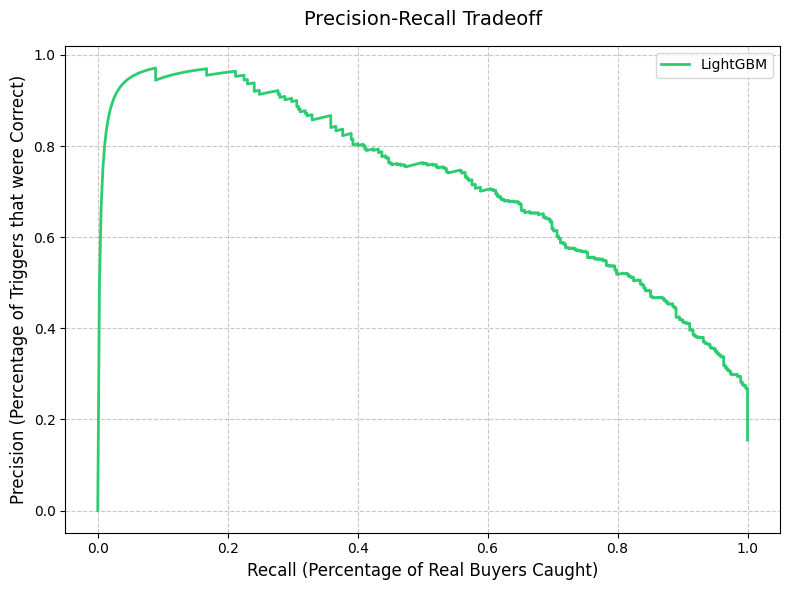

📊 Business Simulation at Threshold: 0.5
----------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2084
           1       0.58      0.72      0.64       382

    accuracy                           0.88      2466
   macro avg       0.77      0.81      0.78      2466
weighted avg       0.89      0.88      0.88      2466

Total True Buyers Caught: 274
True Buyers Missed (Slipped through): 108
False Positives (Money wasted on window shoppers): 195
📊 Business Simulation at Threshold: 0.35
----------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2084
           1       0.54      0.79      0.64       382

    accuracy                           0.86      2466
   macro avg       0.75      0.83      0.78      2466
weighted avg       0.89      0.86      0.87      2466

Total True Buyers Caught: 303
True Buyers Missed (Slippe

In [3]:
# 1. Import our new evaluation toolkit
from marketing_evaluation import plot_pr_curve, evaluate_threshold

# 2. Get the raw probabilities from the model (not the hard 0/1 predictions)
# [:, 1] grabs the probability specifically for class 1 (Converted)
y_probs = optimized_lgbm.predict_proba(X_test)[:, 1]

# 3. Plot the landscape
print("Visualizing the Precision-Recall Landscape...")
plot_pr_curve(y_test, y_probs)

# 4. Test drive a few different business strategies!
# Strategy A: The Balanced Default (0.50)
evaluate_threshold(y_test, y_probs, threshold=0.50)

# Strategy B: The "Aggressive Net" - Catch everyone, sacrifice margin (0.35)
evaluate_threshold(y_test, y_probs, threshold=0.35)

# Strategy C: The "Margin Protector" - Only trigger if we are absolutely sure (0.70)
evaluate_threshold(y_test, y_probs, threshold=0.70)

Calculating SHAP values... (this might take a few seconds)


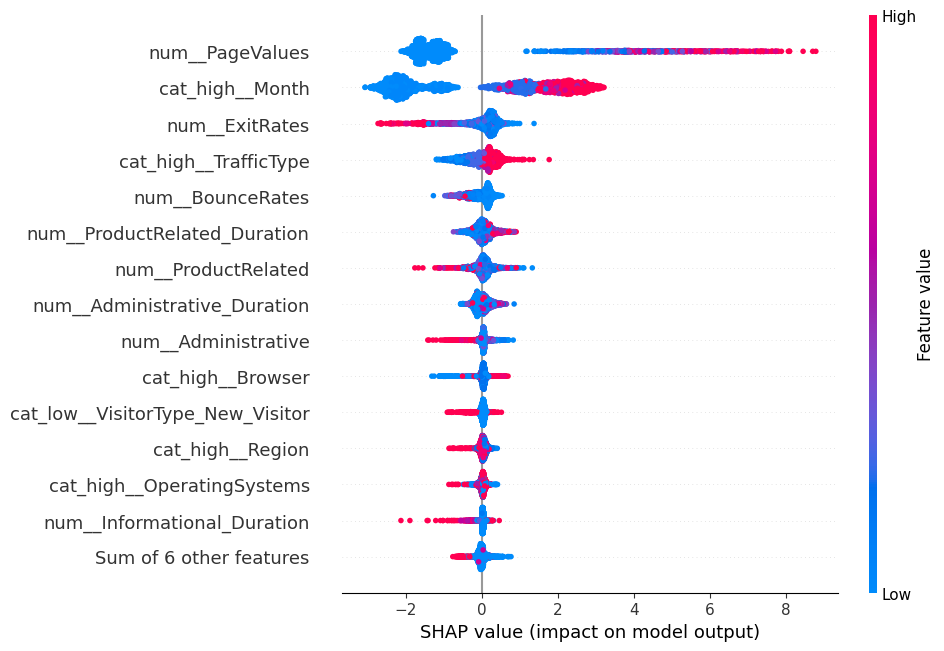

In [4]:
# pip install shap (if we haven't already!)
import shap
import pandas as pd

# 1. Extract the individual pieces from our fitted pipeline
fitted_preprocessor = optimized_lgbm.named_steps['preprocessor']
fitted_model = optimized_lgbm.named_steps['classifier']

# 2. Push our test data through the preprocessor manually
# This converts our strings into Target Encoded probabilities and One-Hot arrays
X_test_transformed = fitted_preprocessor.transform(X_test)

# 3. Extract the clean feature names from the preprocessor
feature_names = fitted_preprocessor.get_feature_names_out()

# 4. Repackage the transformed matrix into a DataFrame so SHAP can read the column names
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 5. Initialize the SHAP Explainer
# TreeExplainer is heavily optimized for LightGBM, running in C++ under the hood
explainer = shap.TreeExplainer(fitted_model)

# 6. Calculate the SHAP values (this calculates the Shapley math for every single user)
print("Calculating SHAP values... (this might take a few seconds)")
shap_values = explainer(X_test_shap)

# 7. Plot the Beeswarm!
shap.plots.beeswarm(shap_values, max_display=15)

Generating SHAP Interaction Plot...


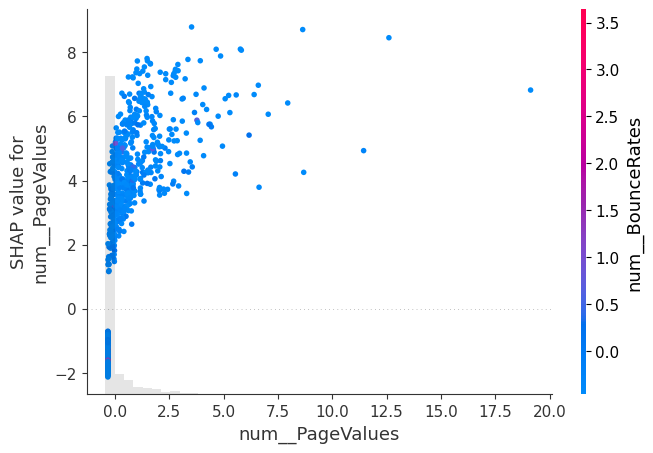

In [11]:
# Create a dependence plot for PageValues, colored by BounceRates
print("Generating SHAP Interaction Plot...")

# We use the exact column names outputted by our preprocessor
shap.plots.scatter(
    shap_values[:, "num__PageValues"], 
    color=shap_values_sampled[:, "num__BounceRates"]
)

In [16]:
import joblib
import os

# 1. Create a models directory if we don't have one yet
os.makedirs('../models', exist_ok=True)

# 2. Define the path for our artifact
artifact_path = '../models/conversion_engine_v1.joblib'

# 3. Freeze the entire fitted pipeline!
print("Exporting master pipeline...")
joblib.dump(optimized_lgbm, artifact_path)

print(f"✅ Pipeline successfully saved to: {artifact_path}")

Exporting master pipeline...
✅ Pipeline successfully saved to: ../models/conversion_engine_v1.joblib


In [17]:
# 1. The Server boots up and loads the frozen engine
live_server_model = joblib.load('../models/conversion_engine_v1.joblib')

# 2. A new user lands on the website (grabbing 1 random row from our test set)
new_visitor = X_test.sample(1, random_state=42)

# 3. The Server instantly cleans the data and predicts the probability of conversion
conversion_prob = live_server_model.predict_proba(new_visitor)[:, 1][0]

print(f"Incoming Visitor Data:\n{new_visitor[['PageValues', 'BounceRates', 'TrafficType']].to_string(index=False)}")
print("-" * 40)
print(f"🔮 Real-Time Conversion Probability: {conversion_prob:.1%}")

Incoming Visitor Data:
 PageValues  BounceRates  TrafficType
        0.0     0.002439            1
----------------------------------------
🔮 Real-Time Conversion Probability: 0.0%
